Task-1

Input tensor shape:
  Training   : (2100, 128, 9)
  Validation : (450, 128, 9)
  Testing    : (450, 128, 9)
Number of classes: 6
Number of features per time step: 9
Sequence length: 128
train {'WALKING': np.int64(351), 'WALKING_UPSTAIRS': np.int64(315), 'WALKING_DOWNSTAIRS': np.int64(286), 'SITTING': np.int64(363), 'STANDING': np.int64(389), 'LAYING': np.int64(396)}
val {'WALKING': np.int64(76), 'WALKING_UPSTAIRS': np.int64(68), 'WALKING_DOWNSTAIRS': np.int64(61), 'SITTING': np.int64(77), 'STANDING': np.int64(83), 'LAYING': np.int64(85)}
test {'WALKING': np.int64(75), 'WALKING_UPSTAIRS': np.int64(67), 'WALKING_DOWNSTAIRS': np.int64(62), 'SITTING': np.int64(78), 'STANDING': np.int64(83), 'LAYING': np.int64(85)}


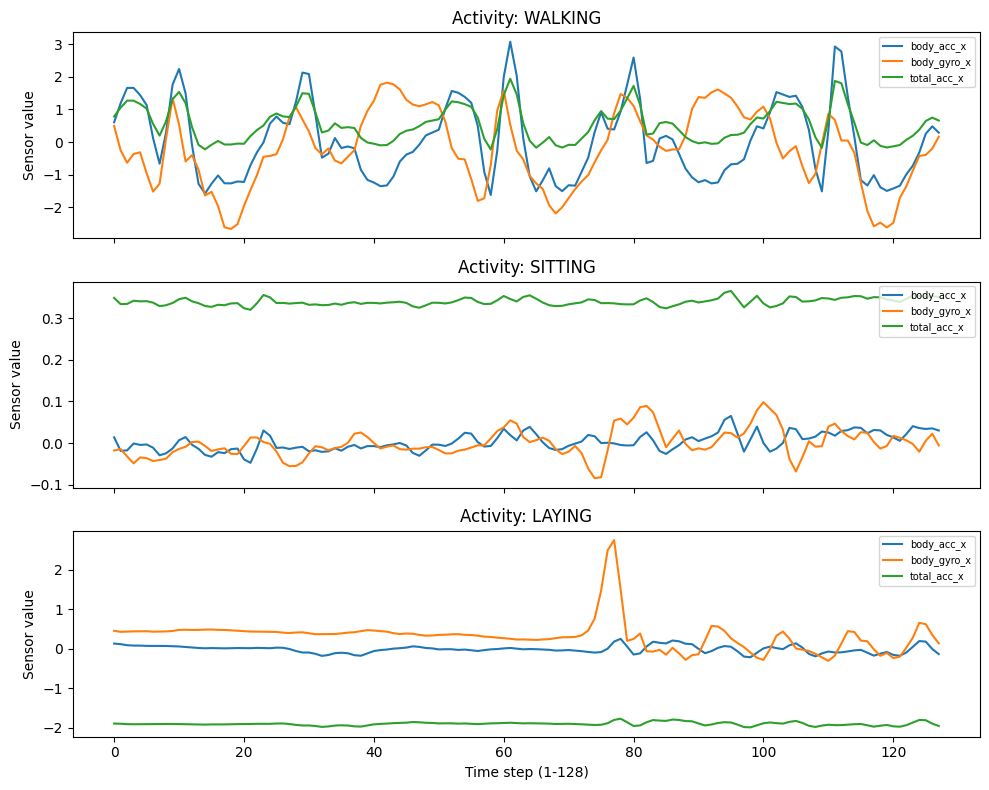


Inference (Plot 1):
1. Periodic/oscillatory temporal patterns are visible for dynamic activities
   (WALKING), while static activities (SITTING, LAYING) show flat, low-variance signals.
2. SITTING and STANDING tend to exhibit similar, near-static patterns and are
   the most easily confused pair.
3. Ordering matters because activity is defined by motion over time — shuffling
   the 128 steps would destroy the periodicity/trend information the model relies on.



In [1]:
!pip -q install tensorflow scikit-learn matplotlib numpy

import os, zipfile, urllib.request
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
URL = "https://archive.ics.uci.edu/static/public/240/human+activity+recognition+using+smartphones.zip"
DATA_DIR = "/content/har_data"
os.makedirs(DATA_DIR, exist_ok=True)
zip_path = os.path.join(DATA_DIR, "har.zip")

if not os.path.exists(zip_path):
    urllib.request.urlretrieve(URL, zip_path)
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(DATA_DIR)
    inner_zip = os.path.join(DATA_DIR, "UCI HAR Dataset.zip")
    if os.path.exists(inner_zip):
        with zipfile.ZipFile(inner_zip, "r") as z:
            z.extractall(DATA_DIR)

BASE = os.path.join(DATA_DIR, "UCI HAR Dataset")

SIGNALS = [
    "body_acc_x", "body_acc_y", "body_acc_z",
    "body_gyro_x", "body_gyro_y", "body_gyro_z",
    "total_acc_x", "total_acc_y", "total_acc_z",
]
ACTIVITY_NAMES = ["WALKING", "WALKING_UPSTAIRS", "WALKING_DOWNSTAIRS",
                  "SITTING", "STANDING", "LAYING"]

def load_split(split):
    """Load one split ('train' or 'test') -> (N, 128, 9), (N,)"""
    signal_dir = os.path.join(BASE, split, "Inertial Signals")
    channels = []
    for sig in SIGNALS:
        fname = os.path.join(signal_dir, f"{sig}_{split}.txt")
        channels.append(np.loadtxt(fname))          # (N, 128)
    X = np.stack(channels, axis=-1)                  # (N, 128, 9)
    y = np.loadtxt(os.path.join(BASE, split, f"y_{split}.txt")).astype(int) - 1  # 0-indexed
    return X, y

X_tr_raw, y_tr_raw = load_split("train")
X_te_raw, y_te_raw = load_split("test")
X_all = np.concatenate([X_tr_raw, X_te_raw], axis=0)
y_all = np.concatenate([y_tr_raw, y_te_raw], axis=0)

N_SUBSET = 3000
X_subset, _, y_subset, _ = train_test_split(
    X_all, y_all, train_size=N_SUBSET, stratify=y_all, random_state=42
)
X_train, X_temp, y_train, y_temp = train_test_split(
    X_subset, y_subset, test_size=0.30, stratify=y_subset, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

# Normalize using TRAIN statistics only (per-channel)
mean = X_train.mean(axis=(0, 1), keepdims=True)
std = X_train.std(axis=(0, 1), keepdims=True) + 1e-8
X_train = (X_train - mean) / std
X_val = (X_val - mean) / std
X_test = (X_test - mean) / std

NUM_CLASSES = 6
SEQ_LEN = 128
NUM_FEATURES = 9

print("Input tensor shape:")
print(f"  Training   : {X_train.shape}")
print(f"  Validation : {X_val.shape}")
print(f"  Testing    : {X_test.shape}")
print(f"Number of classes: {NUM_CLASSES}")
print(f"Number of features per time step: {NUM_FEATURES}")
print(f"Sequence length: {SEQ_LEN}")

# Class distribution check
for name, y in [("train", y_train), ("val", y_val), ("test", y_test)]:
    counts = np.bincount(y, minlength=NUM_CLASSES)
    print(name, dict(zip(ACTIVITY_NAMES, counts)))

# ---------------------------------------------------------
# 6. Temporal Data Visualization (Plot 1)
# ---------------------------------------------------------
classes_to_show = [0, 3, 5]  # WALKING, SITTING, LAYING
channels_to_show = [0, 3, 6]  # body_acc_x, body_gyro_x, total_acc_x

fig, axes = plt.subplots(len(classes_to_show), 1, figsize=(10, 8), sharex=True)
for ax, cls in zip(axes, classes_to_show):
    idx = np.where(y_train == cls)[0][0]
    for ch in channels_to_show:
        ax.plot(range(SEQ_LEN), X_train[idx, :, ch], label=SIGNALS[ch])
    ax.set_title(f"Activity: {ACTIVITY_NAMES[cls]}")
    ax.set_ylabel("Sensor value")
    ax.legend(fontsize=7, loc="upper right")
axes[-1].set_xlabel("Time step (1-128)")
plt.tight_layout()
plt.savefig("plot1_temporal_signals.png", dpi=150)
plt.show()

print("""
Inference (Plot 1):
1. Periodic/oscillatory temporal patterns are visible for dynamic activities
   (WALKING), while static activities (SITTING, LAYING) show flat, low-variance signals.
2. SITTING and STANDING tend to exhibit similar, near-static patterns and are
   the most easily confused pair.
3. Ordering matters because activity is defined by motion over time — shuffling
   the 128 steps would destroy the periodicity/trend information the model relies on.
""")

Task-2

In [2]:
import time
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
x = [0.5, 0.7, 0.2]
h0, Wx, Wh, b = 0.0, 0.5, 0.8, 0.1

h_prev = h0
h_manual = []
for xt in x:
    h_t = np.tanh(Wx * xt + Wh * h_prev + b)
    h_manual.append(h_t)
    h_prev = h_t

print("Manually computed hidden states:")
for i, h in enumerate(h_manual, 1):
    print(f"  h{i} = {h:.6f}")
rnn_cell = layers.SimpleRNNCell(1)
rnn_cell.build(input_shape=(None, 1))
rnn_cell.set_weights([
    np.array([[Wx]], dtype=np.float32),
    np.array([[Wh]], dtype=np.float32),
    np.array([b], dtype=np.float32),
])

h_state = tf.zeros((1, 1))
h_program = []
for xt in x:
    inp = tf.constant([[xt]], dtype=tf.float32)
    out, [h_state] = rnn_cell(inp, [h_state])
    h_program.append(float(out.numpy()[0, 0]))

print("\nProgram-computed hidden states:")
for i, h in enumerate(h_program, 1):
    print(f"  h{i} = {h:.6f}")

print("\nInference: manual and program values match, confirming the "
      "tanh(Wx*x + Wh*h_prev + b) recurrence used at every BPTT time step.")
def build_rnn(seq_len=128, num_features=9, num_classes=6, units=32):
    model = models.Sequential([
        layers.Input(shape=(seq_len, num_features)),
        layers.SimpleRNN(units),
        layers.Dropout(0.2),
        layers.Dense(16, activation="relu"),
        layers.Dense(num_classes, activation="softmax"),
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
                   loss="sparse_categorical_crossentropy",
                   metrics=["accuracy"])
    return model

model_rnn = build_rnn(SEQ_LEN, NUM_FEATURES, NUM_CLASSES, units=32)
model_rnn.summary()

start = time.time()
history_rnn = model_rnn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30, batch_size=32, verbose=2
)
time_rnn = time.time() - start
print(f"RNN training time: {time_rnn:.2f} s")
try:
    histories
except NameError:
    histories = {}
try:
    models_dict
except NameError:
    models_dict = {}
try:
    train_times
except NameError:
    train_times = {}

histories["RNN"] = history_rnn
models_dict["RNN"] = model_rnn
train_times["RNN"] = time_rnn

Manually computed hidden states:
  h1 = 0.336376
  h2 = 0.616352
  h3 = 0.599958

Program-computed hidden states:
  h1 = 0.336376
  h2 = 0.616352
  h3 = 0.599958

Inference: manual and program values match, confirming the tanh(Wx*x + Wh*h_prev + b) recurrence used at every BPTT time step.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,974 (7.71 KB)

 Trainable params: 1,974 (7.71 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
66/66 - 6s - 96ms/step - accuracy: 0.4705 - loss: 1.4367 - val_accuracy: 0.5822 - val_loss: 1.1755
Epoch 2/30
66/66 - 1s - 11ms/step - accuracy: 0.5748 - loss: 1.0916 - val_accuracy: 0.5533 - val_loss: 1.0967
Epoch 3/30
66/66 - 1s - 11ms/step - accuracy: 0.5738 - loss: 1.0183 - val_accuracy: 0.6044 - val_loss: 0.9582
Epoch 4/30
66/66 - 1s - 11ms/step - accuracy: 0.6281 - loss: 0.8940 - val_accuracy: 0.6578 - val_loss: 0.8212
Epoch 5/30
66/66 - 1s - 17ms/step - accuracy: 0.6533 - loss: 0.8280 - val_accuracy: 0.6644 - val_loss: 0.7686
Epoch 6/30
66/66 - 1s - 16ms/step - accuracy: 0.6595 - loss: 0.7811 - val_accuracy: 0.6689 - val_loss: 0.7283
Epoch 7/30
66/66 - 1s - 13ms/step - accuracy: 0.6867 - loss: 0.7321 - val_accuracy: 0.6689 - val_loss: 0.7404
Epoch 8/30
66/66 - 1s - 12ms/step - accuracy: 0.6138 - loss: 0.9162 - val_accuracy: 0.6622 - val_loss: 0.7256
Epoch 9/30
66/66 - 1s - 11ms/step - accuracy: 0.6767 - loss: 0.7180 - val_accuracy: 0.7044 - val_loss: 0.6491
Epoch 10/3

Task-3

In [3]:

import time
import tensorflow as tf
from tensorflow.keras import layers, models

def build_lstm(seq_len=128, num_features=9, num_classes=6, units=32):
    model = models.Sequential([
        layers.Input(shape=(seq_len, num_features)),
        layers.LSTM(units),
        layers.Dropout(0.2),
        layers.Dense(16, activation="relu"),
        layers.Dense(num_classes, activation="softmax"),
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
                   loss="sparse_categorical_crossentropy",
                   metrics=["accuracy"])
    return model

model_lstm = build_lstm(SEQ_LEN, NUM_FEATURES, NUM_CLASSES, units=32)
model_lstm.summary()

start = time.time()
history_lstm = model_lstm.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30, batch_size=32, verbose=2
)
time_lstm = time.time() - start
print(f"LSTM training time: {time_lstm:.2f} s")

try:
    histories
except NameError:
    histories = {}
try:
    models_dict
except NameError:
    models_dict = {}
try:
    train_times
except NameError:
    train_times = {}

histories["LSTM"] = history_lstm
models_dict["LSTM"] = model_lstm
train_times["LSTM"] = time_lstm

print("""
Inference (Section 10):
The forget gate lets the LSTM discard irrelevant past information from the
cell state, the input gate controls how much new candidate information is
written in, and the output gate controls how much of the cell state is
exposed as the hidden state. Because the cell state is updated additively
(Ct = ft*Ct-1 + it*C~t) rather than through repeated matrix multiplication
alone, gradients can flow across many time steps with far less vanishing
than in a Vanilla RNN, letting the network retain long-term dependencies.
""")

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         5,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,006 (23.46 KB)

 Trainable params: 6,006 (23.46 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
66/66 - 6s - 90ms/step - accuracy: 0.3933 - loss: 1.6059 - val_accuracy: 0.6067 - val_loss: 1.3078
Epoch 2/30
66/66 - 1s - 10ms/step - accuracy: 0.6019 - loss: 1.1654 - val_accuracy: 0.6311 - val_loss: 0.9938
Epoch 3/30
66/66 - 1s - 12ms/step - accuracy: 0.6505 - loss: 0.9511 - val_accuracy: 0.6533 - val_loss: 0.8162
Epoch 4/30
66/66 - 1s - 11ms/step - accuracy: 0.6648 - loss: 0.7654 - val_accuracy: 0.7022 - val_loss: 0.6778
Epoch 5/30
66/66 - 1s - 19ms/step - accuracy: 0.7276 - loss: 0.6699 - val_accuracy: 0.7511 - val_loss: 0.6028
Epoch 6/30
66/66 - 1s - 10ms/step - accuracy: 0.7776 - loss: 0.6034 - val_accuracy: 0.8356 - val_loss: 0.5087
Epoch 7/30
66/66 - 1s - 10ms/step - accuracy: 0.8471 - loss: 0.4866 - val_accuracy: 0.8689 - val_loss: 0.5055
Epoch 8/30
66/66 - 1s - 11ms/step - accuracy: 0.8519 - loss: 0.4552 - val_accuracy: 0.8711 - val_loss: 0.3644
Epoch 9/30
66/66 - 1s - 10ms/step - accuracy: 0.8438 - loss: 0.4142 - val_accuracy: 0.8289 - val_loss: 0.4344
Epoch 10/3

Task-4

In [4]:

import time
import tensorflow as tf
from tensorflow.keras import layers, models

def build_gru(seq_len=128, num_features=9, num_classes=6, units=32):
    model = models.Sequential([
        layers.Input(shape=(seq_len, num_features)),
        layers.GRU(units),
        layers.Dropout(0.2),
        layers.Dense(16, activation="relu"),
        layers.Dense(num_classes, activation="softmax"),
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
                   loss="sparse_categorical_crossentropy",
                   metrics=["accuracy"])
    return model

model_gru = build_gru(SEQ_LEN, NUM_FEATURES, NUM_CLASSES, units=32)
model_gru.summary()

start = time.time()
history_gru = model_gru.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30, batch_size=32, verbose=2
)
time_gru = time.time() - start
print(f"GRU training time: {time_gru:.2f} s")

try:
    histories
except NameError:
    histories = {}
try:
    models_dict
except NameError:
    models_dict = {}
try:
    train_times
except NameError:
    train_times = {}

histories["GRU"] = history_gru
models_dict["GRU"] = model_gru
train_times["GRU"] = time_gru

print("""
Inference (Section 11):
GRU merges LSTM's forget and input gates into a single update gate (zt) and
uses a reset gate (rt) to control how much past hidden state contributes to
the candidate state. With only two gates and a single hidden state (no
separate cell state), GRU has fewer parameters than LSTM while retaining a
gating mechanism that mitigates vanishing gradients.
""")

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,758 (18.59 KB)

 Trainable params: 4,758 (18.59 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
66/66 - 2s - 34ms/step - accuracy: 0.3910 - loss: 1.5395 - val_accuracy: 0.4622 - val_loss: 1.3363
Epoch 2/30
66/66 - 1s - 11ms/step - accuracy: 0.4805 - loss: 1.2407 - val_accuracy: 0.5778 - val_loss: 1.0600
Epoch 3/30
66/66 - 2s - 26ms/step - accuracy: 0.6114 - loss: 0.8739 - val_accuracy: 0.6444 - val_loss: 0.6971
Epoch 4/30
66/66 - 3s - 51ms/step - accuracy: 0.6652 - loss: 0.6793 - val_accuracy: 0.7089 - val_loss: 0.6071
Epoch 5/30
66/66 - 2s - 30ms/step - accuracy: 0.6971 - loss: 0.6297 - val_accuracy: 0.7444 - val_loss: 0.5573
Epoch 6/30
66/66 - 1s - 22ms/step - accuracy: 0.7581 - loss: 0.5699 - val_accuracy: 0.7978 - val_loss: 0.4887
Epoch 7/30
66/66 - 2s - 27ms/step - accuracy: 0.8000 - loss: 0.4833 - val_accuracy: 0.8244 - val_loss: 0.4148
Epoch 8/30
66/66 - 1s - 10ms/step - accuracy: 0.8148 - loss: 0.4196 - val_accuracy: 0.8711 - val_loss: 0.3575
Epoch 9/30
66/66 - 1s - 10ms/step - accuracy: 0.8790 - loss: 0.3531 - val_accuracy: 0.9022 - val_loss: 0.2960
Epoch 10/3

Task-5

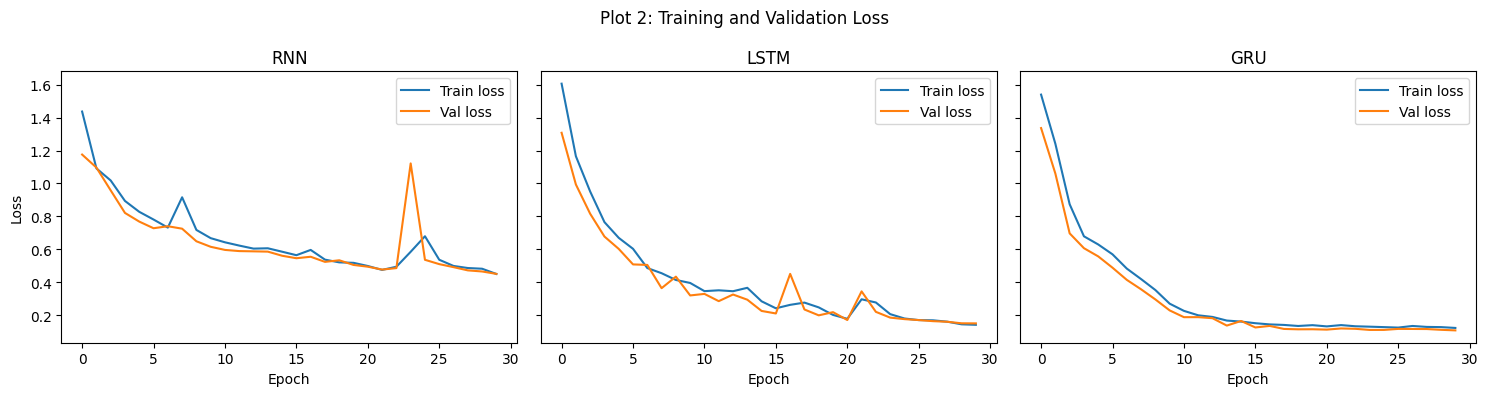

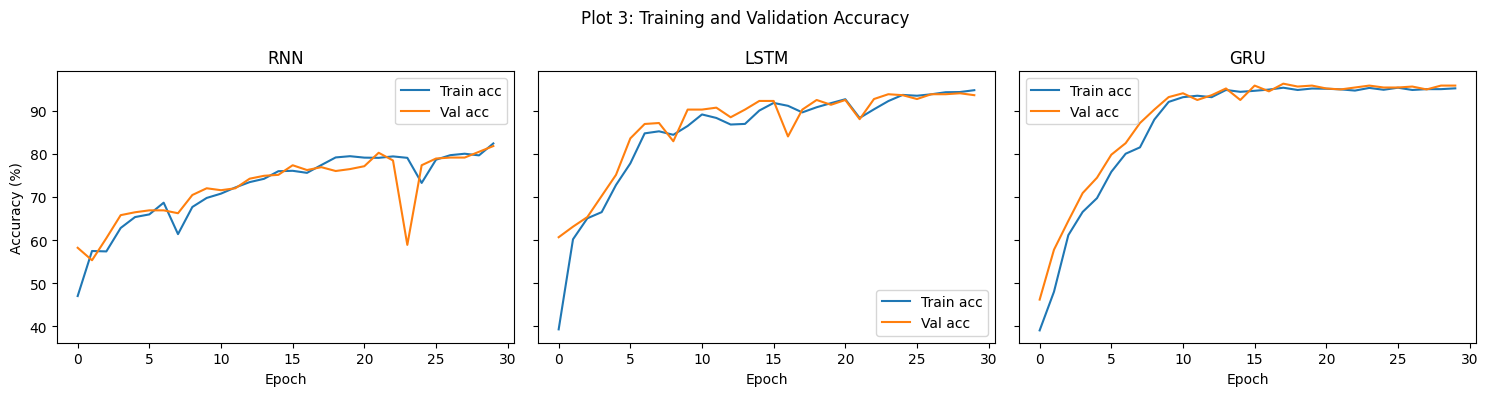


Inference (Plots 2 & 3):
- RNN: loss/accuracy typically plateaus earlier and at a worse level, and the
  train/val gap can be erratic due to unstable gradients over 128 steps.
- LSTM/GRU: smoother, faster convergence and a smaller generalization gap
  because the gating mechanisms stabilize gradient flow across time steps.
- Any widening gap between training and validation curves in later epochs
  indicates overfitting; a training curve that plateaus at high loss
  indicates underfitting (most likely for the RNN given vanishing gradients).



In [6]:

import matplotlib.pyplot as plt

model_names = ["RNN", "LSTM", "GRU"]
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, name in zip(axes, model_names):
    h = histories[name].history
    ax.plot(h["loss"], label="Train loss")
    ax.plot(h["val_loss"], label="Val loss")
    ax.set_title(name)
    ax.set_xlabel("Epoch")
    ax.legend()
axes[0].set_ylabel("Loss")
plt.suptitle("Plot 2: Training and Validation Loss")
plt.tight_layout()
plt.savefig("plot2_loss_curves.png", dpi=150)
plt.show()

# Plot 3: Training vs Validation Accuracy (one subplot per model)
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, name in zip(axes, model_names):
    h = histories[name].history
    ax.plot([a * 100 for a in h["accuracy"]], label="Train acc")
    ax.plot([a * 100 for a in h["val_accuracy"]], label="Val acc")
    ax.set_title(name)
    ax.set_xlabel("Epoch")
    ax.legend()
axes[0].set_ylabel("Accuracy (%)")
plt.suptitle("Plot 3: Training and Validation Accuracy")
plt.tight_layout()
plt.savefig("plot3_accuracy_curves.png", dpi=150)
plt.show()

print("""
Inference (Plots 2 & 3):
- RNN: loss/accuracy typically plateaus earlier and at a worse level, and the
  train/val gap can be erratic due to unstable gradients over 128 steps.
- LSTM/GRU: smoother, faster convergence and a smaller generalization gap
  because the gating mechanisms stabilize gradient flow across time steps.
- Any widening gap between training and validation curves in later epochs
  indicates overfitting; a training curve that plateaus at high loss
  indicates underfitting (most likely for the RNN given vanishing gradients).
""")

Task-6


RNN — Accuracy: 82.22% | Precision: 82.33% | Recall: 81.27% | F1: 81.28% | Params: 1974 | Train time: 29.32s

LSTM — Accuracy: 95.33% | Precision: 95.56% | Recall: 95.55% | F1: 95.54% | Params: 6006 | Train time: 29.12s

GRU — Accuracy: 94.67% | Precision: 95.07% | Recall: 94.93% | F1: 94.97% | Params: 4758 | Train time: 30.71s


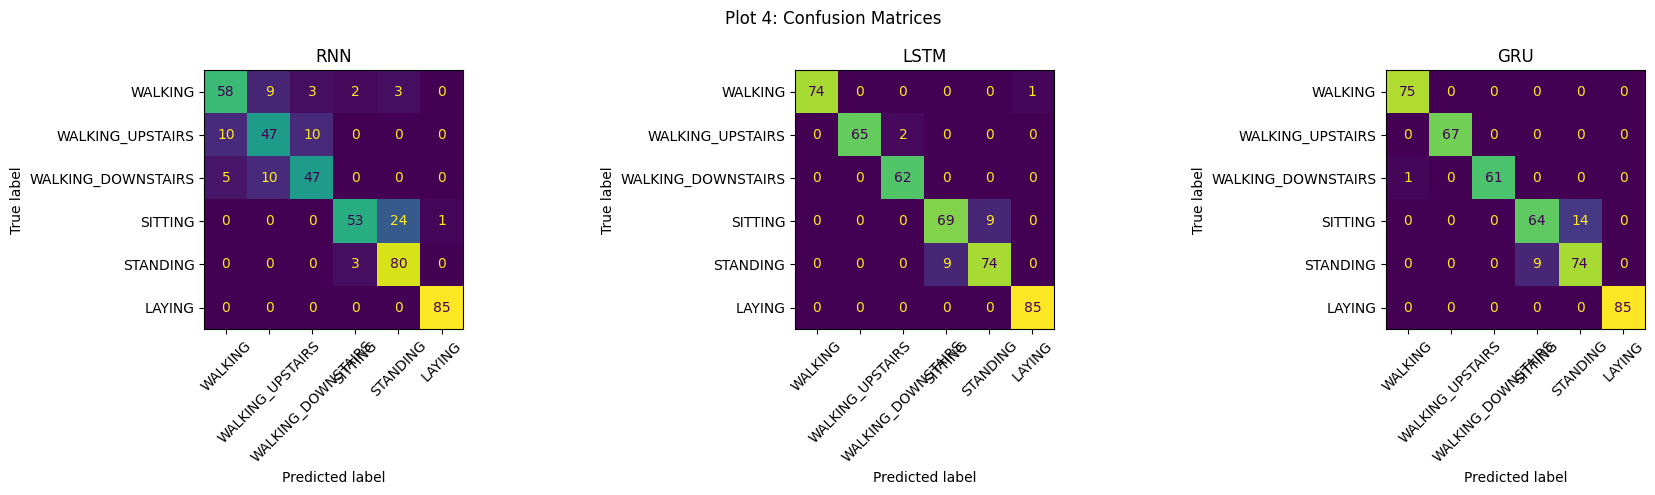


Metric      | RNN     | LSTM    | GRU
accuracy    |   82.22 |   95.33 |   94.67
precision   |   82.33 |   95.56 |   95.07
recall      |   81.27 |   95.55 |   94.93
f1          |   81.28 |   95.54 |   94.97

Inference (Section 15 — base your final wording on YOUR actual matrices):
- Identify the activity with the highest diagonal value (highest recognition rate).
- Identify the activity with the most off-diagonal mass (most misclassified).
- SITTING and STANDING are commonly confused across all three models because
  their sensor signatures are both near-static.
- Compare whether the same confusion pairs recur across RNN, LSTM and GRU —
  consistent confusions point to a data/feature limitation rather than a
  model-specific weakness.



In [7]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay)

model_names = ["RNN", "LSTM", "GRU"]
results = {}   # shared across later tasks

for name in model_names:
    model = models_dict[name]
    y_prob = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)

    acc = accuracy_score(y_test, y_pred) * 100
    prec = precision_score(y_test, y_pred, average="macro", zero_division=0) * 100
    rec = recall_score(y_test, y_pred, average="macro", zero_division=0) * 100
    f1 = f1_score(y_test, y_pred, average="macro", zero_division=0) * 100
    n_params = model.count_params()

    results[name] = {
        "accuracy": acc, "precision": prec, "recall": rec, "f1": f1,
        "params": n_params, "time": train_times.get(name, np.nan),
        "y_pred": y_pred,
    }

    print(f"\n{name} — Accuracy: {acc:.2f}% | Precision: {prec:.2f}% | "
          f"Recall: {rec:.2f}% | F1: {f1:.2f}% | Params: {n_params} | "
          f"Train time: {train_times.get(name, float('nan')):.2f}s")

# Plot 4: Confusion matrix per model
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, name in zip(axes, model_names):
    cm = confusion_matrix(y_test, results[name]["y_pred"])
    disp = ConfusionMatrixDisplay(cm, display_labels=ACTIVITY_NAMES)
    disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
    ax.set_title(name)
plt.suptitle("Plot 4: Confusion Matrices")
plt.tight_layout()
plt.savefig("plot4_confusion_matrices.png", dpi=150)
plt.show()

# Summary table
print("\nMetric      | RNN     | LSTM    | GRU")
for metric in ["accuracy", "precision", "recall", "f1"]:
    row = " | ".join(f"{results[n][metric]:7.2f}" for n in model_names)
    print(f"{metric:11s} | {row}")

print("""
Inference (Section 15 — base your final wording on YOUR actual matrices):
- Identify the activity with the highest diagonal value (highest recognition rate).
- Identify the activity with the most off-diagonal mass (most misclassified).
- SITTING and STANDING are commonly confused across all three models because
  their sensor signatures are both near-static.
- Compare whether the same confusion pairs recur across RNN, LSTM and GRU —
  consistent confusions point to a data/feature limitation rather than a
  model-specific weakness.
""")

Task-7

Property       |      RNN |     LSTM |      GRU
Hidden state   |      Yes |      Yes |      Yes
Cell state     |       No |      Yes |       No
Forget gate    |       No |      Yes |       No
Input gate     |       No |      Yes |       No
Output gate    |       No |      Yes |       No
Update gate    |       No |       No |      Yes
Reset gate     |       No |       No |      Yes
Parameters     |     1974 |     6006 |     4758
Training time  |    29.32 |    29.12 |    30.71
Test F1-score  |    81.28 |    95.54 |    94.97


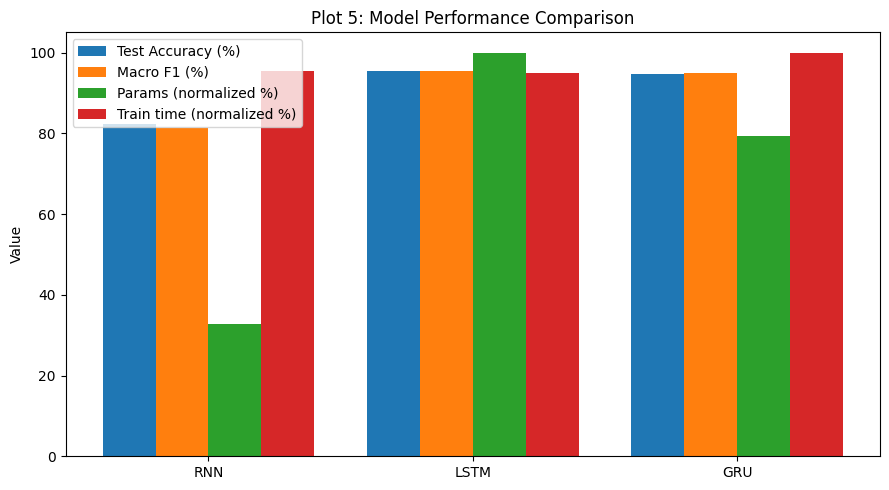


Inference (Section 16):
There is a clear trade-off between predictive performance, model complexity
and training cost: LSTM/GRU typically outperform the Vanilla RNN in
accuracy/F1 because gating mitigates vanishing gradients, but they carry
more parameters (LSTM > GRU > RNN, since LSTM has 4 gate weight sets, GRU
has 3, RNN has 1) and longer per-epoch training time. GRU is usually a good
middle ground — close to LSTM's accuracy with fewer parameters and faster
training, making it attractive when compute budget is constrained.



In [8]:

import matplotlib.pyplot as plt
import numpy as np

model_names = ["RNN", "LSTM", "GRU"]

# --- Comparison table ---
gate_table = {
    "Hidden state": ["Yes", "Yes", "Yes"],
    "Cell state":   ["No", "Yes", "No"],
    "Forget gate":  ["No", "Yes", "No"],
    "Input gate":   ["No", "Yes", "No"],
    "Output gate":  ["No", "Yes", "No"],
    "Update gate":  ["No", "No", "Yes"],
    "Reset gate":   ["No", "No", "Yes"],
}

print(f"{'Property':14s} | {'RNN':>8s} | {'LSTM':>8s} | {'GRU':>8s}")
for prop, vals in gate_table.items():
    print(f"{prop:14s} | {vals[0]:>8s} | {vals[1]:>8s} | {vals[2]:>8s}")

print(f"{'Parameters':14s} | " + " | ".join(f"{results[n]['params']:8d}" for n in model_names))
print(f"{'Training time':14s} | " + " | ".join(f"{results[n]['time']:8.2f}" for n in model_names))
print(f"{'Test F1-score':14s} | " + " | ".join(f"{results[n]['f1']:8.2f}" for n in model_names))

# --- Plot 5: Bar chart of Accuracy, Macro F1 and normalized params/time ---
accs = [results[n]["accuracy"] for n in model_names]
f1s = [results[n]["f1"] for n in model_names]
params = np.array([results[n]["params"] for n in model_names], dtype=float)
times = np.array([results[n]["time"] for n in model_names], dtype=float)
params_norm = params / params.max() * 100
times_norm = times / times.max() * 100

x = np.arange(len(model_names))
width = 0.2

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - 1.5 * width, accs, width, label="Test Accuracy (%)")
ax.bar(x - 0.5 * width, f1s, width, label="Macro F1 (%)")
ax.bar(x + 0.5 * width, params_norm, width, label="Params (normalized %)")
ax.bar(x + 1.5 * width, times_norm, width, label="Train time (normalized %)")
ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.set_ylabel("Value")
ax.set_title("Plot 5: Model Performance Comparison")
ax.legend()
plt.tight_layout()
plt.savefig("plot5_model_comparison.png", dpi=150)
plt.show()

print("""
Inference (Section 16):
There is a clear trade-off between predictive performance, model complexity
and training cost: LSTM/GRU typically outperform the Vanilla RNN in
accuracy/F1 because gating mitigates vanishing gradients, but they carry
more parameters (LSTM > GRU > RNN, since LSTM has 4 gate weight sets, GRU
has 3, RNN has 1) and longer per-epoch training time. GRU is usually a good
middle ground — close to LSTM's accuracy with fewer parameters and faster
training, making it attractive when compute budget is constrained.
""")

Task-8

T= 32 | RNN  | Test F1 = 73.57%
T= 32 | LSTM | Test F1 = 91.06%
T= 32 | GRU  | Test F1 = 93.12%
T= 64 | RNN  | Test F1 = 63.40%
T= 64 | LSTM | Test F1 = 93.99%
T= 64 | GRU  | Test F1 = 93.74%
T=128 | RNN  | Test F1 = 74.88%
T=128 | LSTM | Test F1 = 93.72%
T=128 | GRU  | Test F1 = 94.93%

Sequence Length | RNN F1 | LSTM F1 | GRU F1
             32 |  73.57 |   91.06 |  93.12
             64 |  63.40 |   93.99 |  93.74
            128 |  74.88 |   93.72 |  94.93


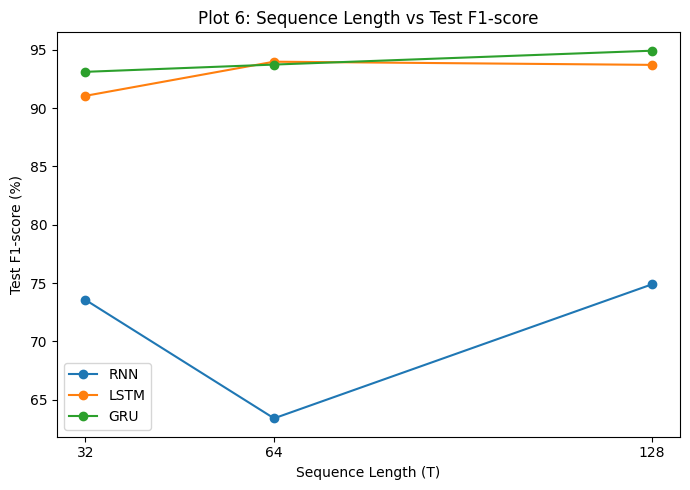


Inference (Section 17):
More temporal context (larger T) generally improves F1-score because the
model observes more of the activity cycle, which especially benefits
periodic activities like WALKING. Vanilla RNN tends to gain the least (or
even degrade) at T=128 due to vanishing gradients over the longer unrolled
sequence, while LSTM/GRU are better able to exploit the additional context.



In [9]:

import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt

SEQ_LENGTHS = [32, 64, 128]
LAYER_MAP = {"RNN": layers.SimpleRNN, "LSTM": layers.LSTM, "GRU": layers.GRU}

def truncate(X, T):
    """Keep the first T time steps (consistent truncation for all samples)."""
    return X[:, :T, :]

def build_model(layer_cls, seq_len, num_features=9, num_classes=6, units=32):
    model = models.Sequential([
        layers.Input(shape=(seq_len, num_features)),
        layer_cls(units),
        layers.Dropout(0.2),
        layers.Dense(16, activation="relu"),
        layers.Dense(num_classes, activation="softmax"),
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
                   loss="sparse_categorical_crossentropy",
                   metrics=["accuracy"])
    return model

seqlen_f1 = {name: [] for name in LAYER_MAP}

for T in SEQ_LENGTHS:
    Xtr_T = truncate(X_train, T)
    Xval_T = truncate(X_val, T)
    Xte_T = truncate(X_test, T)

    for name, layer_cls in LAYER_MAP.items():
        model = build_model(layer_cls, T)
        model.fit(Xtr_T, y_train, validation_data=(Xval_T, y_val),
                  epochs=15, batch_size=32, verbose=0)
        y_pred = np.argmax(model.predict(Xte_T, verbose=0), axis=1)
        f1 = f1_score(y_test, y_pred, average="macro", zero_division=0) * 100
        seqlen_f1[name].append(f1)
        print(f"T={T:3d} | {name:4s} | Test F1 = {f1:.2f}%")

# Table
print("\nSequence Length | RNN F1 | LSTM F1 | GRU F1")
for i, T in enumerate(SEQ_LENGTHS):
    print(f"{T:15d} | {seqlen_f1['RNN'][i]:6.2f} | "
          f"{seqlen_f1['LSTM'][i]:7.2f} | {seqlen_f1['GRU'][i]:6.2f}")

# Plot 6
plt.figure(figsize=(7, 5))
for name in LAYER_MAP:
    plt.plot(SEQ_LENGTHS, seqlen_f1[name], marker="o", label=name)
plt.xlabel("Sequence Length (T)")
plt.ylabel("Test F1-score (%)")
plt.title("Plot 6: Sequence Length vs Test F1-score")
plt.xticks(SEQ_LENGTHS)
plt.legend()
plt.tight_layout()
plt.savefig("plot6_seqlen_vs_f1.png", dpi=150)
plt.show()

print("""
Inference (Section 17):
More temporal context (larger T) generally improves F1-score because the
model observes more of the activity cycle, which especially benefits
periodic activities like WALKING. Vanilla RNN tends to gain the least (or
even degrade) at T=128 due to vanishing gradients over the longer unrolled
sequence, while LSTM/GRU are better able to exploit the additional context.
""")

Task-9

CNN feature dimension D = 1280
Feature tensor supplied to recurrent network: (55, 10, 1280)


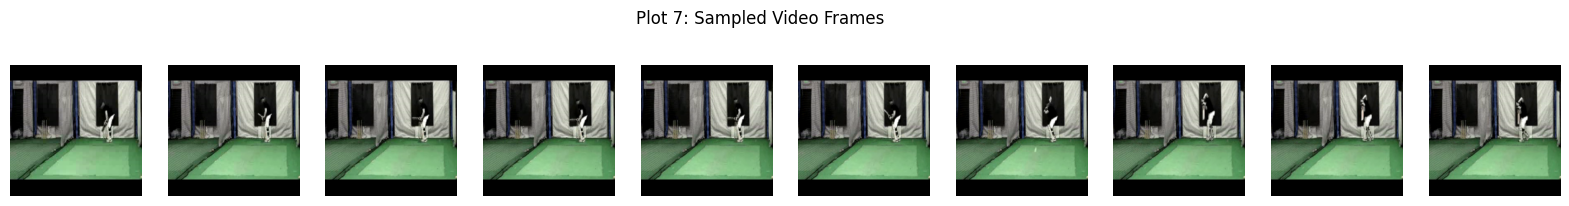

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 32)             │       168,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 168,163 (656.89 KB)

 Trainable params: 168,163 (656.89 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
8/8 - 1s - 156ms/step - accuracy: 0.6875 - loss: 0.7922 - val_accuracy: 0.8889 - val_loss: 0.4665
Epoch 2/20
8/8 - 0s - 18ms/step - accuracy: 1.0000 - loss: 0.2401 - val_accuracy: 1.0000 - val_loss: 0.2175
Epoch 3/20
8/8 - 0s - 16ms/step - accuracy: 1.0000 - loss: 0.1230 - val_accuracy: 1.0000 - val_loss: 0.1439
Epoch 4/20
8/8 - 0s - 17ms/step - accuracy: 1.0000 - loss: 0.0634 - val_accuracy: 1.0000 - val_loss: 0.0786
Epoch 5/20
8/8 - 0s - 16ms/step - accuracy: 1.0000 - loss: 0.0468 - val_accuracy: 1.0000 - val_loss: 0.0869
Epoch 6/20
8/8 - 0s - 18ms/step - accuracy: 1.0000 - loss: 0.0370 - val_accuracy: 1.0000 - val_loss: 0.0639
Epoch 7/20
8/8 - 0s - 20ms/step - accuracy: 1.0000 - loss: 0.0313 - val_accuracy: 1.0000 - val_loss: 0.0520
Epoch 8/20
8/8 - 0s - 25ms/step - accuracy: 1.0000 - loss: 0.0269 - val_accuracy: 1.0000 - val_loss: 0.0462
Epoch 9/20
8/8 - 0s - 37ms/step - accuracy: 1.0000 - loss: 0.0231 - val_accuracy: 1.0000 - val_loss: 0.0443
Epoch 10/20
8/8 - 0s - 41ms

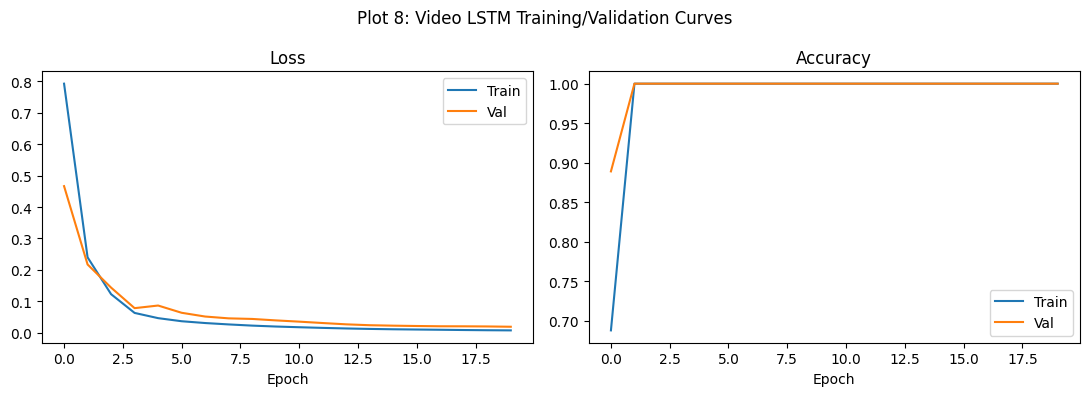

Predicted class : CricketShot
Actual class    : CricketShot
Confidence      : 0.99

Predicted class : CricketShot
Actual class    : CricketShot
Confidence      : 0.99

Predicted class : CricketShot
Actual class    : CricketShot
Confidence      : 0.99

Predicted class : Punch
Actual class    : Punch
Confidence      : 1.00

Predicted class : Punch
Actual class    : Punch
Confidence      : 0.99

Video LSTM — Test Accuracy: 100.00% | Macro F1: 100.00%


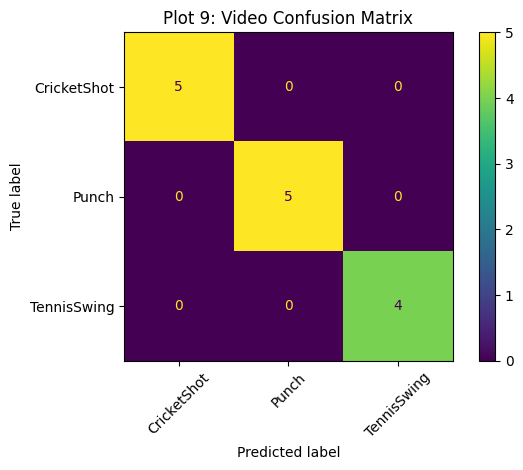


Inference (Sections 20-21):
The frozen CNN captures spatial appearance in each frame (objects, pose,
scene context — e.g. a ball or a bicycle), while the LSTM/GRU models how
those per-frame features evolve across the 10-frame sequence, capturing the
motion pattern that distinguishes actions such as CricketShot vs TennisSwing.



In [14]:
# =========================================================
# Experiment 6 — Task 9: Video Understanding (CNN + LSTM/GRU)
# Sections 18–21 (Plots 7, 8, 9)
# Independent of earlier tasks — run standalone in Colab.
# NOTE: Downloads a small UCF101 subset. UCF101 is large, so this
# script pulls a handful of clips per class from a mirrored subset.
# Adjust CLASSES / VIDEOS_PER_CLASS to fit your time/compute budget.
# =========================================================

!pip -q install opencv-python-headless tensorflow scikit-learn matplotlib pandas

import os, glob, time
import numpy as np
import pandas as pd
import cv2
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score, confusion_matrix,
                              ConfusionMatrixDisplay)
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 18. Dataset — small UCF101 subset (auto-downloaded, no manual step)
# ---------------------------------------------------------
# The original storage.googleapis.com/thumos14_files mirror now returns 403
# for anonymous/Colab access, so this uses a pre-packaged UCF101 subset
# hosted on GitHub Releases instead (the same one used by the official Keras
# "Video Classification with a CNN-RNN Architecture" example). It ships
# train.csv / test.csv plus train/ and test/ folders of .avi clips for 5
# classes: CricketShot, PlayingCello, Punch, ShavingBeard, TennisSwing.
DATA_ROOT = "/content/ucf101_top5"
if not os.path.exists(DATA_ROOT):
    os.makedirs(DATA_ROOT, exist_ok=True)
    tar_path = "/content/ucf101_top5.tar.gz"
    os.system(
        "wget -q https://github.com/sayakpaul/Action-Recognition-in-TensorFlow/"
        f"releases/download/v1.0.0/ucf101_top5.tar.gz -O {tar_path}"
    )
    os.system(f"tar xf {tar_path} -C {DATA_ROOT}")

# Pick which of the 5 available classes to use (edit as needed)
CLASSES = ["CricketShot", "Punch", "TennisSwing"]
VIDEOS_PER_CLASS = 20   # cap per class so the lab run stays quick
NUM_FRAMES = 10
IMG_SIZE = 224

train_df = pd.read_csv(os.path.join(DATA_ROOT, "train.csv"))
test_df = pd.read_csv(os.path.join(DATA_ROOT, "test.csv"))
full_df = pd.concat([
    train_df.assign(split="train"), test_df.assign(split="test")
], ignore_index=True)
full_df = full_df[full_df["tag"].isin(CLASSES)]

def video_path_for_row(row):
    return os.path.join(DATA_ROOT, row["split"], row["video_name"])

def sample_frames(video_path, num_frames=NUM_FRAMES, size=IMG_SIZE):
    cap = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total <= 0:
        cap.release()
        return None
    idxs = np.linspace(0, max(total - 1, 0), num_frames).astype(int)
    frames = []
    for i in range(total):
        ret, frame = cap.read()
        if not ret:
            break
        if i in idxs:
            frame = cv2.resize(frame, (size, size))
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frames.append(frame)
    cap.release()
    if len(frames) < num_frames:
        return None
    return np.stack(frames[:num_frames])  # (num_frames, 224, 224, 3)

# ---------------------------------------------------------
# 20. CNN Feature Extraction (frozen MobileNetV2, GAP head)
# ---------------------------------------------------------
cnn_base = MobileNetV2(include_top=False, weights="imagenet",
                        input_shape=(IMG_SIZE, IMG_SIZE, 3), pooling="avg")
cnn_base.trainable = False
FEATURE_DIM = cnn_base.output_shape[-1]
print(f"CNN feature dimension D = {FEATURE_DIM}")

def extract_video_features(frames):
    """frames: (10, 224, 224, 3) uint8 -> (10, D) feature sequence"""
    x = preprocess_input(frames.astype(np.float32))
    feats = cnn_base.predict(x, verbose=0)  # (10, D)
    return feats

X_feat, y_vid, sample_frame_grid = [], [], None
for label, cls in enumerate(CLASSES):
    rows = full_df[full_df["tag"] == cls].head(VIDEOS_PER_CLASS)
    for _, row in rows.iterrows():
        vf = video_path_for_row(row)
        if not os.path.exists(vf):
            continue
        frames = sample_frames(vf)
        if frames is None:
            continue
        if sample_frame_grid is None:
            sample_frame_grid = frames  # keep one example for Plot 7
        feats = extract_video_features(frames)
        X_feat.append(feats)
        y_vid.append(label)

X_feat = np.array(X_feat)          # (B, 10, D)
y_vid = np.array(y_vid)
print(f"Feature tensor supplied to recurrent network: {X_feat.shape}")

if len(X_feat) < len(CLASSES) * 2:
    raise RuntimeError(
        f"Only {len(X_feat)} usable video(s) were loaded from {DATA_ROOT}. "
        "Check that the download step above completed (re-run it), or lower "
        "NUM_FRAMES / try different CLASSES if some videos are too short."
    )

Xv_train, Xv_test, yv_train, yv_test = train_test_split(
    X_feat, y_vid, test_size=0.25, stratify=y_vid, random_state=42
)
Xv_train, Xv_val, yv_train, yv_val = train_test_split(
    Xv_train, yv_train, test_size=0.2, stratify=yv_train, random_state=42
)

# Plot 7: representative sampled frames
if sample_frame_grid is not None:
    fig, axes = plt.subplots(1, NUM_FRAMES, figsize=(20, 2.5))
    for ax, frame in zip(axes, sample_frame_grid):
        ax.imshow(frame)
        ax.axis("off")
    plt.suptitle("Plot 7: Sampled Video Frames")
    plt.savefig("plot7_video_frames.png", dpi=150)
    plt.show()

# ---------------------------------------------------------
# 21. CNN–LSTM / CNN–GRU classifier
# ---------------------------------------------------------
def build_video_classifier(layer_type="LSTM", feature_dim=FEATURE_DIM,
                            num_frames=NUM_FRAMES, num_classes=len(CLASSES), units=32):
    RecLayer = layers.LSTM if layer_type == "LSTM" else layers.GRU
    model = models.Sequential([
        layers.Input(shape=(num_frames, feature_dim)),
        RecLayer(units),
        layers.Dense(num_classes, activation="softmax"),
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                   loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

RECURRENT_TYPE = "LSTM"  # switch to "GRU" to compare (Additional Exercise 6)
video_model = build_video_classifier(RECURRENT_TYPE)
video_model.summary()

history_video = video_model.fit(
    Xv_train, yv_train, validation_data=(Xv_val, yv_val),
    epochs=20, batch_size=4, verbose=2
)

# Plot 8: video training/validation curves
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(history_video.history["loss"], label="Train")
axes[0].plot(history_video.history["val_loss"], label="Val")
axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend()
axes[1].plot(history_video.history["accuracy"], label="Train")
axes[1].plot(history_video.history["val_accuracy"], label="Val")
axes[1].set_title("Accuracy"); axes[1].set_xlabel("Epoch"); axes[1].legend()
plt.suptitle(f"Plot 8: Video {RECURRENT_TYPE} Training/Validation Curves")
plt.tight_layout()
plt.savefig("plot8_video_curves.png", dpi=150)
plt.show()

# Evaluation + Plot 9: confusion matrix
y_prob = video_model.predict(Xv_test, verbose=0)
y_pred = np.argmax(y_prob, axis=1)
conf = np.max(y_prob, axis=1)

for i in range(min(5, len(yv_test))):
    print(f"Predicted class : {CLASSES[y_pred[i]]}")
    print(f"Actual class    : {CLASSES[yv_test[i]]}")
    print(f"Confidence      : {conf[i]:.2f}\n")

acc = accuracy_score(yv_test, y_pred) * 100
f1 = f1_score(yv_test, y_pred, average="macro", zero_division=0) * 100
print(f"Video {RECURRENT_TYPE} — Test Accuracy: {acc:.2f}% | Macro F1: {f1:.2f}%")

cm = confusion_matrix(yv_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=CLASSES).plot(xticks_rotation=45)
plt.title("Plot 9: Video Confusion Matrix")
plt.tight_layout()
plt.savefig("plot9_video_confusion.png", dpi=150)
plt.show()

print("""
Inference (Sections 20-21):
The frozen CNN captures spatial appearance in each frame (objects, pose,
scene context — e.g. a ball or a bicycle), while the LSTM/GRU models how
those per-frame features evolve across the 10-frame sequence, capturing the
motion pattern that distinguishes actions such as CricketShot vs TennisSwing.
""")

Task-10

In [15]:

import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
VOCAB_MIN, VOCAB_MAX = 0, 9          # integer range
SEQ_LEN = 4
NUM_SAMPLES = 5000
VOCAB_SIZE = VOCAB_MAX + 1
START_TOKEN = VOCAB_SIZE             # extra token id for decoder "go" symbol
FULL_VOCAB = VOCAB_SIZE + 1

rng = np.random.default_rng(42)

def make_dataset(n):
    X = rng.integers(VOCAB_MIN, VOCAB_MAX + 1, size=(n, SEQ_LEN))
    Y = X[:, ::-1]
    return X, Y

X_all, Y_all = make_dataset(NUM_SAMPLES)
dec_input = np.concatenate([np.full((NUM_SAMPLES, 1), START_TOKEN), Y_all[:, :-1]], axis=1)
dec_target = Y_all

split = int(0.85 * NUM_SAMPLES)
X_train, X_test = X_all[:split], X_all[split:]
dec_in_train, dec_in_test = dec_input[:split], dec_input[split:]
dec_tgt_train, dec_tgt_test = dec_target[:split], dec_target[split:]

LATENT_DIM = 64

# Encoder
enc_inputs = layers.Input(shape=(SEQ_LEN,), name="encoder_input")
enc_emb = layers.Embedding(FULL_VOCAB, LATENT_DIM)(enc_inputs)
_, state_h, state_c = layers.LSTM(LATENT_DIM, return_state=True, name="encoder_lstm")(enc_emb)
encoder_states = [state_h, state_c]

# Decoder (teacher forcing during training)
dec_inputs = layers.Input(shape=(SEQ_LEN,), name="decoder_input")
dec_emb = layers.Embedding(FULL_VOCAB, LATENT_DIM)(dec_inputs)
dec_lstm = layers.LSTM(LATENT_DIM, return_sequences=True, return_state=True, name="decoder_lstm")
dec_outputs, _, _ = dec_lstm(dec_emb, initial_state=encoder_states)
dec_dense = layers.Dense(FULL_VOCAB, activation="softmax", name="decoder_output")
dec_outputs = dec_dense(dec_outputs)

seq2seq_model = models.Model([enc_inputs, dec_inputs], dec_outputs)
seq2seq_model.compile(optimizer="adam", loss="sparse_categorical_crossentropy",
                       metrics=["accuracy"])
seq2seq_model.summary()

history_seq2seq = seq2seq_model.fit(
    [X_train, dec_in_train], dec_tgt_train,
    validation_split=0.1, epochs=30, batch_size=64, verbose=2
)

encoder_model = models.Model(enc_inputs, encoder_states)

dec_state_input_h = layers.Input(shape=(LATENT_DIM,))
dec_state_input_c = layers.Input(shape=(LATENT_DIM,))
dec_single_input = layers.Input(shape=(1,))
dec_single_emb = seq2seq_model.get_layer(index=2)(dec_single_input)  # embedding layer reuse
dec_single_out, h, c = dec_lstm(dec_single_emb, initial_state=[dec_state_input_h, dec_state_input_c])
dec_single_out = dec_dense(dec_single_out)
decoder_model = models.Model(
    [dec_single_input, dec_state_input_h, dec_state_input_c],
    [dec_single_out, h, c]
)

def predict_sequence(input_seq):
    states = encoder_model.predict(input_seq[None, :], verbose=0)
    target_tok = np.array([[START_TOKEN]])
    output_tokens = []
    for _ in range(SEQ_LEN):
        out, h, c = decoder_model.predict([target_tok] + states, verbose=0)
        next_tok = np.argmax(out[0, -1, :])
        output_tokens.append(next_tok)
        target_tok = np.array([[next_tok]])
        states = [h, c]
    return np.array(output_tokens)
print("Sample | Input Sequence | Predicted Output")
for i in range(5):
    pred = predict_sequence(X_test[i])
    print(f"{i+1:6d} | {list(X_test[i])} | {list(pred)}")
correct_tokens, total_tokens, correct_seqs = 0, 0, 0
for i in range(len(X_test)):
    pred = predict_sequence(X_test[i])
    target = Y_all[split + i]
    correct_tokens += np.sum(pred == target)
    total_tokens += SEQ_LEN
    if np.array_equal(pred, target):
        correct_seqs += 1

token_acc = correct_tokens / total_tokens
seq_acc = correct_seqs / len(X_test)

print(f"\nToken Accuracy    : {token_acc:.4f}")
print(f"Sequence Accuracy : {seq_acc:.4f}")
print(f"Final Training Loss   : {history_seq2seq.history['loss'][-1]:.4f}")
print(f"Final Validation Loss : {history_seq2seq.history['val_loss'][-1]:.4f}")

print("""
Inference (Section 24):
Sequence accuracy is typically much lower than token accuracy because a
sequence only counts as correct if EVERY token in it is correct — a single
wrong token (e.g. the last element) fails the whole sequence even though
most positions were predicted correctly. Token accuracy averages over
individual positions, so isolated errors are diluted, while sequence
accuracy is an all-or-nothing measure that is far stricter for longer outputs.
""")

Model: "functional_13"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_input       │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 4, 64)     │        704 │ encoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 4, 64)     │        704 │ decoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_lstm (LSTM) │ [(None, 64),      │     33,024 │ embedding[0][0]   │
│                     │ (None, 64),       │            │                   │
│                     │ (None, 64)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_lstm (LSTM) │ [(None, 4, 64),   │     33,024 │ embedding_1[0][0… │
│                     │ (None, 64),       │            │ encoder_lstm[0][… │
│                     │ (None, 64)]       │            │ encoder_lstm[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_output      │ (None, 4, 11)     │        715 │ decoder_lstm[0][… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 68,171 (266.29 KB)

 Trainable params: 68,171 (266.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
60/60 - 12s - 199ms/step - accuracy: 0.3232 - loss: 2.1041 - val_accuracy: 0.3824 - val_loss: 1.6015
Epoch 2/30
60/60 - 4s - 70ms/step - accuracy: 0.4999 - loss: 1.2607 - val_accuracy: 0.7035 - val_loss: 0.8365
Epoch 3/30
60/60 - 1s - 9ms/step - accuracy: 0.8854 - loss: 0.5087 - val_accuracy: 0.9671 - val_loss: 0.2888
Epoch 4/30
60/60 - 1s - 9ms/step - accuracy: 0.9841 - loss: 0.1955 - val_accuracy: 0.9959 - val_loss: 0.1372
Epoch 5/30
60/60 - 1s - 9ms/step - accuracy: 0.9973 - loss: 0.1043 - val_accuracy: 0.9988 - val_loss: 0.0835
Epoch 6/30
60/60 - 1s - 9ms/step - accuracy: 0.9992 - loss: 0.0669 - val_accuracy: 0.9994 - val_loss: 0.0576
Epoch 7/30
60/60 - 1s - 9ms/step - accuracy: 0.9997 - loss: 0.0474 - val_accuracy: 0.9988 - val_loss: 0.0423
Epoch 8/30
60/60 - 1s - 9ms/step - accuracy: 0.9999 - loss: 0.0345 - val_accuracy: 1.0000 - val_loss: 0.0319
Epoch 9/30
60/60 - 1s - 9ms/step - accuracy: 1.0000 - loss: 0.0270 - val_accuracy: 0.9994 - val_loss: 0.0267
Epoch 10/30
60/